# DATA AUGMENTATION 
This notebook aims to augment the data of railsem by incorporating new pedestrian preset onto safe category images

In [ ]:
import json
import os
from PIL import Image, ImageDraw

# Nom du fichier JSON
json_file = "../../data/images/rs19_val/rs00560.json"

# Chargement du JSON
with open(json_file, 'r') as f:
    data = json.load(f)

frame_name = data["frame"]  # ex: "rs00560"
img_width = data["imgWidth"]
img_height = data["imgHeight"]

# Nom de l'image correspondante (adapter si l'image a une autre extension)
image_file = "../../data/images/rs19_origin/" + frame_name + ".jpg"

# Chargement de l'image source
image = Image.open(image_file).convert("RGBA")

# Sortie dans un dossier
#output_dir = "extracted_persons"
#if not os.path.exists(output_dir):
#    os.makedirs(output_dir)

person_count = 0
person_img= None

for obj in data["objects"]:
    if obj["label"] == "person":
        # On considère que l'objet a un champ "polygon" définissant le piéton
        if "polygon" in obj:
            polygon = obj["polygon"]  # liste de points [ [x1, y1], [x2, y2], ... ]

            # Créer un masque pour ce piéton
            mask = Image.new('L', (img_width, img_height), 0)
            draw = ImageDraw.Draw(mask)
            draw.polygon(polygon, fill=255)

            # Extraire uniquement la zone du piéton
            # On va découper selon la bounding box du polygon pour réduire la taille
            xs = [p[0] for p in polygon]
            ys = [p[1] for p in polygon]
            min_x, max_x = min(xs), max(xs)
            min_y, max_y = min(ys), max(ys)

            # Crée une image vide (transparente) pour la sortie
            person_img = Image.new('RGBA', (max_x - min_x, max_y - min_y), (0,0,0,0))

            # Décale le polygon pour le masque local (si on veut rogner l'image autour du piéton)
            local_polygon = [(x - min_x, y - min_y) for x, y in polygon]

            # Crée un masque local pour le piéton rogné
            local_mask = Image.new('L', (max_x - min_x, max_y - min_y), 0)
            local_draw = ImageDraw.Draw(local_mask)
            local_draw.polygon(local_polygon, fill=255)

            # Colle la portion d'image correspondante
            cropped_region = image.crop((min_x, min_y, max_x, max_y))
            person_img.paste(cropped_region, (0,0), local_mask)

            # Sauvegarde
            person_count += 1
            #output_path = os.path.join(output_dir, f"{frame_name}_person_{person_count}.png")
            #person_img.save(output_path)

print(f"Extraction terminée. {person_count} piéton(s) extrait(s).")


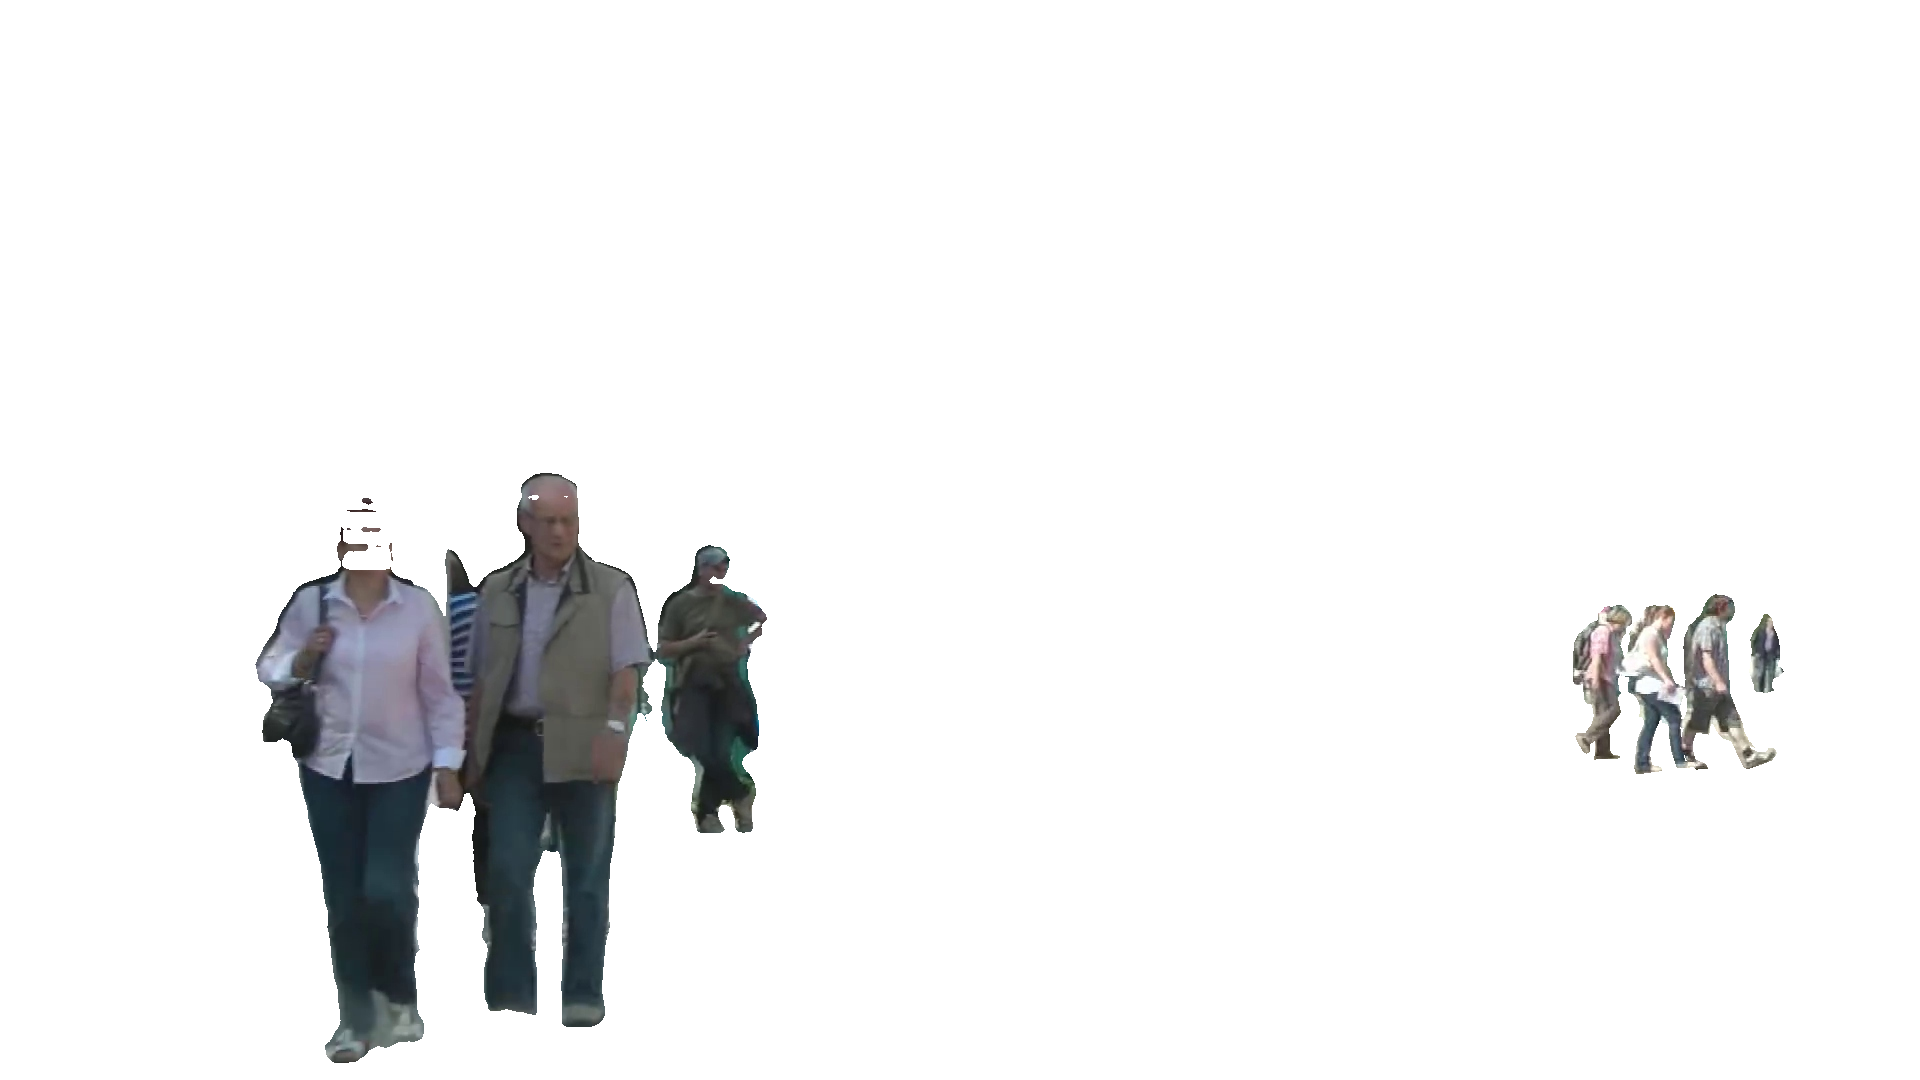

In [3]:
from PIL import Image
import numpy as np
from IPython.display import display

frame_name = "rs00560"
# Les noms de fichiers
image_file = "../../data/images/rs19_origin/"+frame_name+".jpg"
mask_file = "../../data/images/rs19_mask/"+frame_name+".png"

# Charger l'image et le masque
image = Image.open(image_file).convert("RGBA")
mask = Image.open(mask_file).convert("L")

# Convertir en tableaux numpy pour un traitement plus facile
image_np = np.array(image)  # shape: (H, W, 4)
mask_np = np.array(mask)    # shape: (H, W)

# On veut garder uniquement les pixels où mask == 11
# Créer une image RGBA de sortie, initialisée à transparent
output_np = np.zeros_like(image_np)

# Pour les pixels piétons
pedestrian_indices = (mask_np == 11)

# Copier les pixels de l'image originale là où se trouvent des piétons
output_np[pedestrian_indices] = image_np[pedestrian_indices]

# Convertir le numpy array en image PIL
output_img = Image.fromarray(output_np)

# Afficher l'image résultante
display(output_img)


## Sauvegarde le nom + compte des images avec des piétons

In [4]:
import os
from PIL import Image
import numpy as np
import csv

image_dir = "../../data/images/rs19_origin"
mask_dir = "../../data/images/rs19_mask"
output_csv = "images_with_pedestrians.csv"

# On liste les fichiers de masques
mask_files = [f for f in os.listdir(mask_dir) if f.endswith(".png")]

images_with_pedestrians = []

for mask_file in mask_files:
    # Correspondance du masque à l'image :
    # exemple: rs00560_mask.png -> rs00560.jpg
    # Dans le code précédent, le nom est transformé en remplaçant 'png' par 'jpg'
    base_name = mask_file.replace("png", "")
    image_file = base_name + "jpg"
    
    # Ouvrir le masque
    mask_path = os.path.join(mask_dir, mask_file)
    mask = Image.open(mask_path).convert("L")
    mask_np = np.array(mask)
    
    # Compter les pixels == 11 (piétons)
    pedestrian_count = np.sum(mask_np == 11)
    
    # Si l'image contient au moins un piéton, on l'ajoute à la liste
    if pedestrian_count > 0:
        # On peut stocker aussi le nombre de piétons si on veut
        images_with_pedestrians.append((image_file, pedestrian_count))

# Sauvegarde dans un CSV
# La première colonne sera le nom de l'image, la deuxième le nombre de pixels piétons
with open(output_csv, mode='w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["image_file", "pedestrian_pixel_count"])
    for img_name, count in images_with_pedestrians:
        writer.writerow([img_name, count])

print(f"{len(images_with_pedestrians)} images avec des piétons ont été enregistrées dans {output_csv}.")


2403 images avec des piétons ont été enregistrées dans images_with_pedestrians.csv.
